# 01 - Exploracao de Dados de Precos

Este notebook realiza a analise exploratoria dos dados coletados pelo scraper.

Dados coletados de: **https://books.toscrape.com/**

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analyze import load_data, calc_stats, plot_price_distribution, compare_prices, summary_report
from src.scraper import ProductScraper

sns.set_style('whitegrid')

## 1. Coleta de Dados (Scraping)

Executa o scraper para coletar livros do site.

In [2]:
scraper = ProductScraper(delay=1.0)
produtos = scraper.fetch_and_save(
    url='https://books.toscrape.com/',
    name_selector='h3 a',
    price_selector='p.price_color',
    filepath='../data/books.csv'
)
print(f'{len(produtos)} livros coletados')

20 livros coletados


## 2. Carregamento dos Dados

In [3]:
df = load_data('../data/books.csv')
print(f'Total de livros: {len(df)}')
df.head(10)

Total de livros: 20


,nome,preco,url,fonte,data_coleta
0,A Light in the ...,51.77,https://books.toscrape.com/catalogue/a-light-i...,NaN,2026-09-10T15:00:03.982081+00:00
1,Tipping the Velvet,53.74,https://books.toscrape.com/catalogue/tipping-t...,NaN,2026-09-10T15:00:03.982161+00:00
2,Soumission,50.10,https://books.toscrape.com/catalogue/soumissio...,NaN,2026-09-10T15:00:03.982191+00:00
3,Sharp Objects,47.82,https://books.toscrape.com/catalogue/sharp-obj...,NaN,2026-09-10T15:00:03.982209+00:00
4,Sapiens: A Brief History ...,54.23,https://books.toscrape.com/catalogue/sapiens-a...,NaN,2026-09-10T15:00:03.982229+00:00
5,The Requiem Red,22.65,https://books.toscrape.com/catalogue/the-requi...,NaN,2026-09-10T15:00:03.982246+00:00
6,The Dirty Little Secrets ...,33.34,https://books.toscrape.com/catalogue/the-dirty...,NaN,2026-09-10T15:00:03.982259+00:00
7,The Coming Woman: A ...,17.93,https://books.toscrape.com/catalogue/the-comin...,NaN,2026-09-10T15:00:03.982273+00:00
8,The Boys in the ...,22.60,https://books.toscrape.com/catalogue/the-boys-...,NaN,2026-09-10T15:00:03.982287+00:00
9,The Black Maria,52.15,https://books.toscrape.com/catalogue/the-black...,NaN,2026-09-10T15:00:03.982301+00:00


## 3. Estatisticas Descritivas

In [4]:
stats = calc_stats(df)
pd.DataFrame([stats]).T.rename(columns={0: 'Valor'})

,Valor
media,38.048500
mediana,41.380000
desvio_padrao,15.135231
minimo,13.990000
maximo,57.250000
qtd_produtos,20.000000


## 4. Distribuicao de Precos

In [5]:
plot_price_distribution(df)

## 5. Comparacao de Precos

In [6]:
comparacao = compare_prices(df, top_n=5)
comparacao

,nome,preco,url,fonte,data_coleta,categoria
0,Starving Hearts (Triangular Trade ...,13.99,https://books.toscrape.com/catalogue/starving-...,NaN,2026-09-10T15:00:03.982322+00:00,Mais Barato
1,Set Me Free,17.46,https://books.toscrape.com/catalogue/set-me-fr...,NaN,2026-09-10T15:00:03.982352+00:00,Mais Barato
2,The Coming Woman: A ...,17.93,https://books.toscrape.com/catalogue/the-comin...,NaN,2026-09-10T15:00:03.982273+00:00,Mais Barato
3,Shakespeare's Sonnets,20.66,https://books.toscrape.com/catalogue/shakespea...,NaN,2026-09-10T15:00:03.982337+00:00,Mais Barato
4,The Boys in the ...,22.60,https://books.toscrape.com/catalogue/the-boys-...,NaN,2026-09-10T15:00:03.982287+00:00,Mais Barato
5,Our Band Could Be ...,57.25,https://books.toscrape.com/catalogue/our-band-...,NaN,2026-09-10T15:00:03.982394+00:00,Mais Caro
6,Sapiens: A Brief History ...,54.23,https://books.toscrape.com/catalogue/sapiens-a...,NaN,2026-09-10T15:00:03.982229+00:00,Mais Caro
7,Tipping the Velvet,53.74,https://books.toscrape.com/catalogue/tipping-t...,NaN,2026-09-10T15:00:03.982161+00:00,Mais Caro
8,Scott Pilgrim's Precious Little ...,52.29,https://books.toscrape.com/catalogue/scott-pil...,NaN,2026-09-10T15:00:03.982366+00:00,Mais Caro
9,The Black Maria,52.15,https://books.toscrape.com/catalogue/the-black...,NaN,2026-09-10T15:00:03.982301+00:00,Mais Caro


## 6. Relatorio Resumido

In [7]:
relatorio = summary_report(df)
print(relatorio)

=== RELATORIO DE PRECOS ===

Total de produtos: 20
Preco medio: 38.05
Preco mediano: 41.38
Desvio padrao: 15.14
Preco minimo: 13.99
Preco maximo: 57.25



## 7. Analise Adicional: Livros por Faixa de Preco

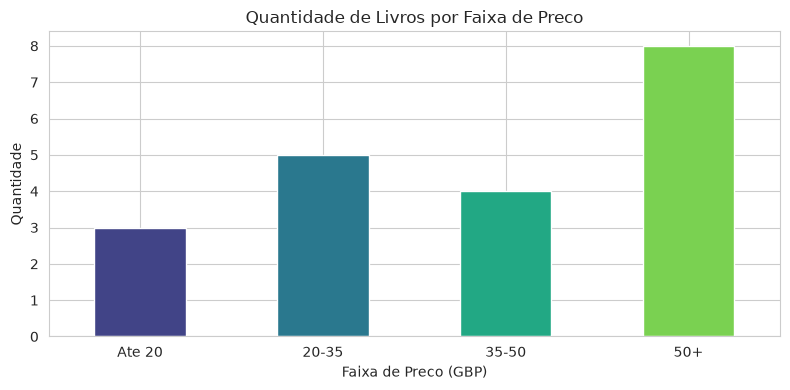

faixa_preco
Ate 20    3
20-35     5
35-50     4
50+       8
Name: count, dtype: int64

In [8]:
bins = [0, 20, 35, 50, 60]
labels = ['Ate 20', '20-35', '35-50', '50+']
df['faixa_preco'] = pd.cut(df['preco'], bins=bins, labels=labels)

faixas = df['faixa_preco'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
faixas.plot(kind='bar', color=sns.color_palette('viridis', len(faixas)), ax=ax)
ax.set_title('Quantidade de Livros por Faixa de Preco')
ax.set_xlabel('Faixa de Preco (GBP)')
ax.set_ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

faixas

## 8. Analise Adicional: Precos com Estatisticas

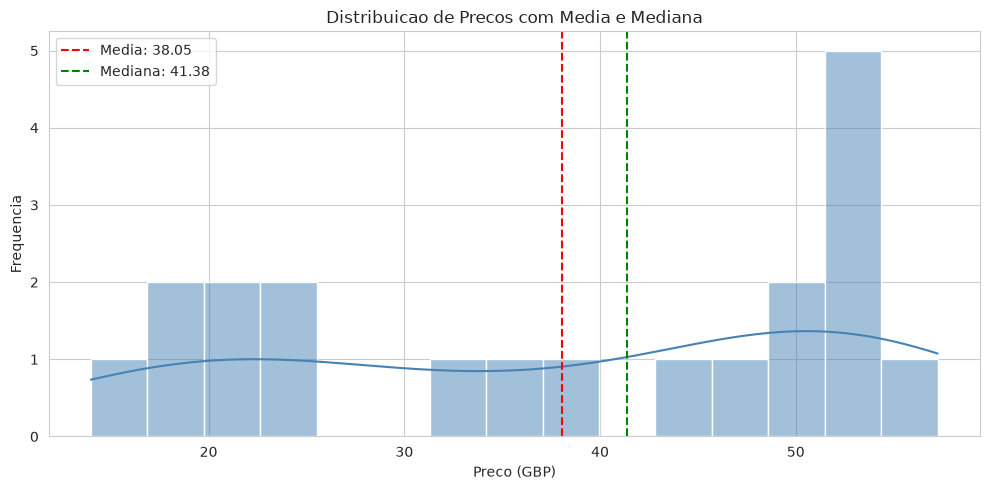

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='preco', bins=15, kde=True, color='steelblue', ax=ax)
ax.axvline(df['preco'].mean(), color='red', linestyle='--', label=f'Media: {df["preco"].mean():.2f}')
ax.axvline(df['preco'].median(), color='green', linestyle='--', label=f'Mediana: {df["preco"].median():.2f}')
ax.set_title('Distribuicao de Precos com Media e Mediana')
ax.set_xlabel('Preco (GBP)')
ax.set_ylabel('Frequencia')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Analise Adicional: Top 10 Mais Baratos

/tmp/ipykernel_45057/3645398698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_baratos, x='preco', y='nome', palette='Greens_r', ax=ax)


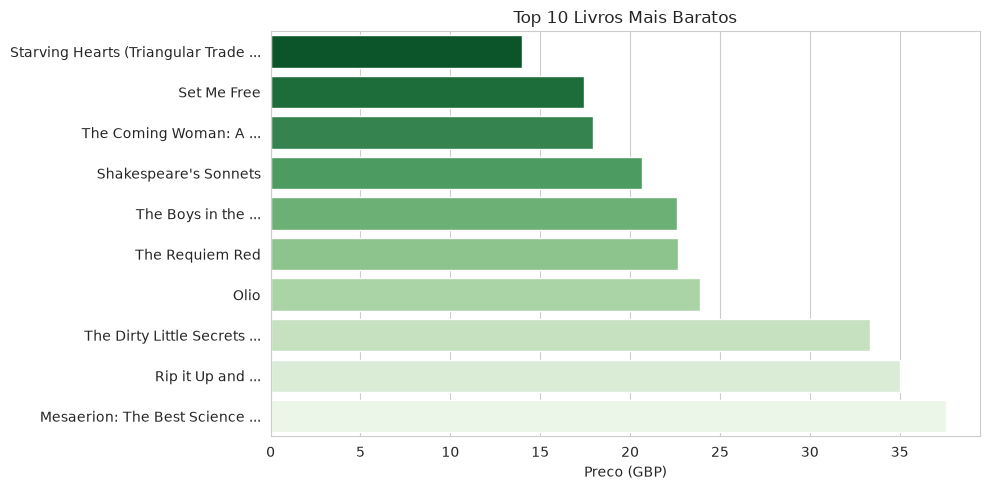

In [10]:
top_baratos = df.nsmallest(10, 'preco')[['nome', 'preco']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_baratos, x='preco', y='nome', palette='Greens_r', ax=ax)
ax.set_title('Top 10 Livros Mais Baratos')
ax.set_xlabel('Preco (GBP)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()